In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch
import torch.nn as nn
import timm
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score


# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
def find_image_file(base_path):
    extensions = ['.png', '.jpg', '.jpeg']
    tried_paths = []
    for ext in extensions:
        file_path = base_path + ext
        tried_paths.append(file_path)
        if os.path.exists(file_path):
            return file_path, tried_paths
    return None, tried_paths

# 定义自定义数据集类 for AfricanPlanesDataset
class AfricanPlanesDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.data_frame = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform
        self.data_frame.columns = self.data_frame.columns.str.strip()
        self.classes = sorted(self.data_frame['Plane'].unique())
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        center = self.data_frame.iloc[idx, self.data_frame.columns.get_loc('Center')].strip()
        filename = self.data_frame.iloc[idx, self.data_frame.columns.get_loc('Filename')].strip()
        base_img_name = os.path.join(self.root_dir, center, filename)
        
        img_name, _ = find_image_file(base_img_name)
        if (img_name is None) or (not os.path.exists(img_name)):
            raise FileNotFoundError(f"Image file not found for base name: {base_img_name}")

        image = Image.open(img_name).convert('RGB')
        label = self.class_to_idx[self.data_frame.iloc[idx, self.data_frame.columns.get_loc('Plane')].strip()]

        if self.transform:
            image = self.transform(image)

        return image, label

# 定义自定义数据集类 for EuropeanPlanesDataset
class CustomDataset(Dataset):
    def __init__(self, csv_file, root_dir, images_dir, transform=None):
        self.data_frame = pd.read_csv(csv_file, sep=';')
        self.root_dir = root_dir
        self.images_dir = images_dir
        self.transform = transform
        self.data_frame.columns = self.data_frame.columns.str.strip()

        lb = LabelBinarizer()
        self.labels = lb.fit_transform(self.data_frame['Plane'])
        self.classes = lb.classes_

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        base_img_name = os.path.join(self.images_dir,
                                     self.data_frame.iloc[idx, self.data_frame.columns.get_loc('Image_name')].strip())

        img_name, _ = find_image_file(base_img_name)
        if (img_name is None) or (not os.path.exists(img_name)):
            raise FileNotFoundError(f"Image file not found for base name: {base_img_name}")

        image = Image.open(img_name).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

# 定义变换
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# AfricanPlanesDataset的文件路径
african_root_dir = '/root/autodl-fs/African/Zenodo_dataset'
african_csv_file_path = '/root/autodl-fs/African/African_planes_database.csv'

# EuropeanPlanesDataset的文件路径
european_root_dir = '/root/autodl-fs/.sys/FETAL_PLANES_ZENODO/FETAL_PLANES_ZENODO'
european_images_dir = os.path.join(european_root_dir, 'Images')
european_csv_file_path = os.path.join(european_root_dir, 'train.csv')  # 假设训练集的CSV文件路径

   
        
# 创建数据集和数据加载器 for AfricanPlanesDataset
african_dataset = AfricanPlanesDataset(csv_file=african_csv_file_path, root_dir=african_root_dir, transform=train_transform)
african_loader = DataLoader(african_dataset, batch_size=16, shuffle=False, pin_memory=True, num_workers=4)


# 创建数据集和数据加载器 for EuropeanPlanesDataset
european_dataset = CustomDataset(csv_file=european_csv_file_path, root_dir=european_root_dir, images_dir=european_images_dir, transform=train_transform)
european_loader = DataLoader(european_dataset, batch_size=16, shuffle=False, pin_memory=True, num_workers=4)


# 创建数据集和数据加载器 for EuropeanPlanesDataset 测试集
european_test_csv_file_path = os.path.join(european_root_dir, 'test.csv')  # 假设测试集的CSV文件路径
if not os.path.exists(european_test_csv_file_path):
    raise FileNotFoundError(f"Test CSV file not found at path: {european_test_csv_file_path}")

european_test_dataset = CustomDataset(csv_file=european_test_csv_file_path, root_dir=european_root_dir, images_dir=european_images_dir, transform=test_transform)
european_test_loader = DataLoader(european_test_dataset, batch_size=1, shuffle=False, pin_memory=True, num_workers=1)  # 修改 batch_size 为 1

# 创建数据集和数据加载器 for AfricanPlanesDataset 测试集
if not os.path.exists(african_csv_file_path):
    raise FileNotFoundError(f"Test CSV file not found at path: {african_csv_file_path}")

african_test_dataset = AfricanPlanesDataset(csv_file=african_csv_file_path, root_dir=african_root_dir, transform=test_transform)
african_test_loader = DataLoader(african_test_dataset, batch_size=1, shuffle=False, pin_memory=True, num_workers=1)  # 修改 batch_size 为 1
print(f"Dataset size: {len(african_test_dataset)}")
image, label = african_test_dataset[0]
print(f"First image size: {image.size()}")
print(f"First image label: {label}")
image, label = african_test_dataset[1]
print(f"2 image size: {image.size()}")
print(f"2 image label: {label}")


Dataset size: 450
First image size: torch.Size([3, 224, 224])
First image label: 0
2 image size: torch.Size([3, 224, 224])
2 image label: 2


In [3]:
# import os
# from PIL import Image
# from torch.utils.data import Dataset

# class MacauDataset(Dataset):
#     def __init__(self, root_dir, transform=None):
#         self.root_dir = root_dir
#         self.transform = transform
#         self.image_paths = []
#         self.labels = []
#         self.classes = []  # 用于存储所有的子文件夹名称（标签）

#         # 遍历根目录下的子文件夹
#         for label in os.listdir(self.root_dir):
#             label_folder = os.path.join(self.root_dir, label)
#             if not os.path.isdir(label_folder):
#                 continue  # 忽略非文件夹项
#             self.classes.append(label)  # 将子文件夹名称作为类别标签
#             for img_name in os.listdir(label_folder):
#                 if img_name.endswith('.jpg'):
#                     img_path = os.path.join(label_folder, img_name)
#                     self.image_paths.append(img_path)
#                     self.labels.append(label)  # 使用子文件夹的名称作为标签

#         # 创建类别到索引的映射
#         self.class_to_idx = {cls: idx for idx, cls in enumerate(sorted(self.classes))}

#     def __len__(self):
#         return len(self.image_paths)

#     def __getitem__(self, idx):
#         img_path = self.image_paths[idx]
#         image = Image.open(img_path).convert('RGB')
#         label_name = self.labels[idx]
#         label = self.class_to_idx[label_name]  # 将标签名称转换为索引

#         if self.transform:
#             image = self.transform(image)

#         return image, label


In [4]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset

class MacauDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.classes = []

        # 遍历根目录下的子文件夹
        for label in os.listdir(self.root_dir):
            label_folder = os.path.join(self.root_dir, label)
            if not os.path.isdir(label_folder):
                continue  # 忽略非文件夹项
            self.classes.append(label)  # 将子文件夹名称作为类别标签
            for img_name in os.listdir(label_folder):
                if img_name.endswith('.jpg'):
                    img_path = os.path.join(label_folder, img_name)
                    self.image_paths.append(img_path)
                    self.labels.append(label)  # 使用子文件夹的名称作为标签

        # 创建类别到索引的映射
        # self.class_to_idx = {cls: idx for idx, cls in enumerate(sorted(self.classes))}
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label_name = self.labels[idx]
        label_idx = self.class_to_idx[label_name]  # 获取标签的数值索引
        label = label_idx 
        if self.transform:
            image = self.transform(image)

        return image, label


# import os
# from PIL import Image
# import torch
# from torch.utils.data import Dataset

# class MacauDataset(Dataset):
#     def __init__(self, root_dir, transform=None):
#         self.root_dir = root_dir
#         self.transform = transform
#         self.image_paths = []
#         self.labels = []
#         self.classes = []

#         # 遍历根目录下的子文件夹
#         for label in os.listdir(self.root_dir):
#             label_folder = os.path.join(self.root_dir, label)
#             if not os.path.isdir(label_folder):
#                 continue  # 忽略非文件夹项
#             self.classes.append(label)  # 将子文件夹名称作为类别标签
#             for img_name in os.listdir(label_folder):
#                 if img_name.endswith('.jpg'):
#                     img_path = os.path.join(label_folder, img_name)
#                     self.image_paths.append(img_path)
#                     self.labels.append(label)  # 使用子文件夹的名称作为标签

#         # 创建类别到索引的映射
#         self.class_to_idx = {cls: idx for idx, cls in enumerate(sorted(self.classes))}

#     def __len__(self):
#         return len(self.image_paths)

#     def __getitem__(self, idx):
#         img_path = self.image_paths[idx]
#         image = Image.open(img_path).convert('RGB')
#         label_name = self.labels[idx]
#         label_idx = self.class_to_idx[label_name]  # 获取标签的数值索引

#         # 转换为PyTorch张量，并确保是形如 [label] 的格式
#         label = torch.tensor([label_idx], dtype=torch.long).to(device='cuda', non_blocking=True)

#         if self.transform:
#             image = self.transform(image)

#         return image, label


In [5]:
# import os
# import pandas as pd
# from PIL import Image
# from torch.utils.data import Dataset
# from torchvision import transforms

# class MacauDataset(Dataset):
#     def __init__(self, root_dir, transform=None):
#         """
#         Args:
#             root_dir (string): 包含类别子文件夹的根目录
#             transform (callable, optional): 对于样本的可选变换
#         """
#         self.root_dir = root_dir
#         self.transform = transform
        
#         # 获取类别文件夹以及对应的类别标签
#         self.classes = sorted(os.listdir(root_dir))  # 类别子文件夹的名字就是label
#         self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        
#         # 收集所有图像路径和它们对应的标签
#         self.image_paths = []
#         self.labels = []
        
#         for class_name in self.classes:
#             class_dir = os.path.join(root_dir, class_name)
#             if os.path.isdir(class_dir):
#                 for img_name in os.listdir(class_dir):
#                     if img_name.endswith('.jpg'):
#                         img_path = os.path.join(class_dir, img_name)
#                         self.image_paths.append(img_path)
#                         self.labels.append(self.class_to_idx[class_name])

#     def __len__(self):
#         return len(self.image_paths)

#     def __getitem__(self, idx):
#         """
#         Args:
#             idx (int): 数据索引
#         Returns:
#             tuple: (image, label)，其中 image 是图像的 Tensor，label 是对应的类别索引
#         """
#         img_path = self.image_paths[idx]
#         image = Image.open(img_path).convert('RGB')
#         label = self.labels[idx]

#         if self.transform:
#             image = self.transform(image)

#         return image, label
    
    # 初始化自定义数据集
    
macau_test_dataset = MacauDataset(root_dir='/root/autodl-fs/Macao/test', transform=test_transform)
macau_test_loader = DataLoader(macau_test_dataset, batch_size=2, shuffle=False, pin_memory=True, num_workers=1)

# 测试数据集长度和获取样本
print(f"Dataset size: {len(macau_test_dataset)}")
image, label = macau_test_dataset[0]
print(f"First image size: {image.size()}")
print(f"First image label: {label}")


Dataset size: 200
First image size: torch.Size([3, 224, 224])
First image label: 0


In [6]:
# import os
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import DataLoader
# from torchvision import transforms, datasets
# from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
# import timm

# # 图像变换
# transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize((0.5,), (0.5,))
# ])

# # 澳门数据集路径
# macau_train_dir = '/root/autodl-fs/Macao/train'
# macau_test_dir = '/root/autodl-fs/Macao/test'

# # 使用ImageFolder创建澳门数据集
# macau_train_dataset = datasets.ImageFolder(root=macau_train_dir, transform=transform)
# macau_test_dataset = datasets.ImageFolder(root=macau_test_dir, transform=transform)

# # 创建数据加载器
# macau_train_loader = DataLoader(macau_train_dataset, batch_size=8, shuffle=True)
# macau_test_loader = DataLoader(macau_test_dataset, batch_size=2, shuffle=False)

# ######################################


# # 打印一下类别标签
# print(f"Classes: {macau_test_dataset.classes}")

In [7]:
# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [8]:
num_classes = 4

# 加载ViT模型和本地预训练权重
model = timm.create_model('vit_base_patch16_224', pretrained=False)
model.load_state_dict(torch.load('/root/autodl-fs/jx_vit_base_p16_224-80ecf9dd.pth'))

# 移除分类头
num_features = model.head.in_features
model.head = nn.Identity()  # 将分类头替换为Identity层

# 定义新的Decoder作为分类头
class Decoder(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(512, num_classes)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# 创建两个Decoder模型
decoder1 = Decoder(num_features, num_classes)
decoder2 = Decoder(num_features, num_classes)
decoder3 = Decoder(num_features, num_classes)

# 创建包含ViT和两个Decoder的联合模型
class CombinedModel(nn.Module):
    def __init__(self, vit, decoder1, decoder2, decoder3):
        super(CombinedModel, self).__init__()
        self.vit = vit
        self.decoder1 = decoder1
        self.decoder2 = decoder2
        self.decoder3 = decoder3
    
    def forward(self, x):
        features = self.vit(x)
        out1 = self.decoder1(features)
        out2 = self.decoder2(features)
        out3 = self.decoder3(features)
        return out1, out2, out3, features

combined_model = CombinedModel(model, decoder1, decoder2, decoder3)
combined_model = combined_model.to(device)

# 冻结ViT模型的权重
for param in combined_model.vit.parameters():
    param.requires_grad = False

# 加载保存的Decoder权重
combined_model.decoder1.load_state_dict(torch.load('/root/autodl-fs/best_decoder_weights1.pth'))  # 非洲
combined_model.decoder2.load_state_dict(torch.load('/root/autodl-fs/best_decoder_weights.pth'))  # 欧洲
combined_model.decoder3.load_state_dict(torch.load('/root/autodl-fs/macau_best_decoder_weights3.pth'))  # 欧洲

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()

# 计算数据集特征的均值和方差（进入ViT前后的图像特征均值和方差）
def compute_mean_std(loader, dataset_name):
    combined_model.eval()
    original_features_list = []
    vit_features_list = []
    with torch.no_grad():
        for inputs, _ in loader:
            inputs = inputs.to(device, non_blocking=True)
            original_features_list.append(inputs.cpu().numpy())
            _, _, _, vit_features = combined_model(inputs)
            vit_features_list.append(vit_features.cpu().numpy())

    original_features = np.concatenate(original_features_list, axis=0)
    vit_features = np.concatenate(vit_features_list, axis=0)

    # 计算每个通道的均值和方差
    original_mean = np.mean(original_features, axis=(0, 2, 3))  # 计算通道维度的均值
    original_std = np.std(original_features, axis=(0, 2, 3))  # 计算通道维度的方差
    vit_mean = np.mean(vit_features, axis=0)  # 计算特征的均值
    vit_std = np.std(vit_features, axis=0)  # 计算特征的方差
    
    # 计算均值
    vit_mean = np.mean(vit_mean)

    # 计算方差
    vit_std = np.var(vit_std)
    
    combined_std = original_std + vit_std
    combined_mean = original_mean + vit_mean

    overall_mean = np.mean(combined_mean)
    overall_std = np.mean(combined_std)

    # print(f"{dataset_name} Dataset Original Mean: {original_mean}")
    # print(f"{dataset_name} Dataset Original Std: {original_std}")
    # print(f"{dataset_name} Dataset ViT Mean: {vit_mean}")
    # print(f"{dataset_name} Dataset ViT Std: {vit_std}")
    print(f"{dataset_name} Dataset combined_mean: {overall_mean}")
    print(f"{dataset_name} Dataset combined_std: {overall_std}")

    return original_mean, original_std, vit_mean, vit_std, overall_mean, overall_std

# 计算欧洲和非洲数据集的均值和方差

europe_original_mean, europe_original_std, europe_vit_mean, europe_vit_std, europe_combined_mean, europe_combined_std = compute_mean_std(european_loader, "European")
africa_original_mean, africa_original_std, africa_vit_mean, africa_vit_std, africa_combined_mean, africa_combined_std = compute_mean_std(african_loader, "African")
macau_original_mean, macau_original_std, macau_vit_mean, macau_vit_std, macau_combined_mean, macau_combined_std = compute_mean_std(macau_test_loader, "Macau")


# 将均值和方差保存在字典中
mean_std_dict = {
    'africa_mean': africa_combined_mean,
    'africa_std': africa_combined_std,
    'europe_mean': europe_combined_mean,
    'europe_std': europe_combined_std,
    'macau_mean': macau_combined_mean,
    'macau_std': macau_combined_std
}



European Dataset combined_mean: -0.7053696513175964
European Dataset combined_std: 0.37093257904052734
African Dataset combined_mean: -0.6107659339904785
African Dataset combined_std: 0.4216914474964142
Macau Dataset combined_mean: -0.6921090483665466
Macau Dataset combined_std: 0.41706883907318115


tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([0, 0], device='cuda:0')
tensor([

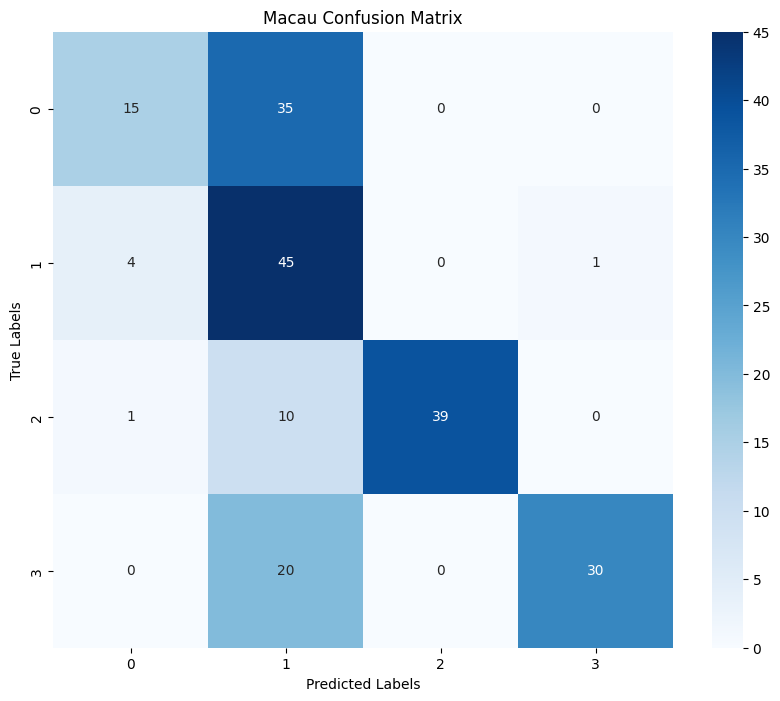

--------------Macau-test-results-------------------------
Test Loss: 2.5742, Test Precision: 0.7817, Test Recall: 0.6450, Test F1-score: 0.6521, Test Accuracy: 0.6450, Test AUC: 0.7806
Test set: 40 images processed by decoder1, 0 images processed by decoder2, 60 images processed by decoder3


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 评估模型的函数
def evaluate(model, test_loader, mean_std_dict):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    total_loss = 0.0
    decoder1_count = 0
    decoder2_count = 0
    decoder3_count = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            labels = labels
            print(labels)
            outputs = model(inputs)

            # 动态解包，根据返回的数量进行判断
            if len(outputs) == 4:
                _, _, _, vit_features = outputs
            else:
                raise ValueError(f"Unexpected number of outputs: {len(outputs)}")

            # 计算 ViT 特征的均值和标准差
            vit_mean = np.mean(vit_features.cpu().numpy(), axis=0)
            vit_std = np.std(vit_features.cpu().numpy(), axis=0)
            
            # 计算图像输入的通道维度的均值和标准差
            original_mean = inputs.mean(dim=(0, 2, 3)).cpu().numpy()
            original_std = inputs.std(dim=(0, 2, 3)).cpu().numpy()

            # 分别处理均值和标准差
            vit_mean_scalar = np.mean(vit_mean)  # ViT 特征整体均值
            vit_std_scalar = np.mean(vit_std)    # ViT 特征整体标准差

            original_mean_scalar = np.mean(original_mean)  # 原始图像均值
            original_std_scalar = np.mean(original_std)    # 原始图像标准差

            combined_mean = original_mean_scalar + vit_mean_scalar
            combined_std = original_std_scalar + vit_std_scalar

            testoverall_mean = np.mean(combined_mean)
            testoverall_std = np.mean(combined_std)

            # 分别比较 ViT 特征和图像特征的均值和方差
            diff_europe_mean = abs(testoverall_mean - mean_std_dict['europe_mean'])
            diff_europe_std = abs(testoverall_std - mean_std_dict['europe_std'])
            diff_africa_mean = abs(testoverall_mean - mean_std_dict['africa_mean'])
            diff_africa_std = abs(testoverall_std - mean_std_dict['africa_std'])
            diff_macau_mean = abs(testoverall_mean - mean_std_dict['macau_mean'])
            diff_macau_std = abs(testoverall_std - mean_std_dict['macau_std'])

            # 选择合适的Decoder
            if diff_africa_mean + 10 * diff_africa_std < diff_europe_mean + 10 * diff_europe_std and \
               diff_africa_mean + 10 * diff_africa_std < diff_macau_mean + 10 * diff_macau_std:
                outputs = model.decoder1(model.vit(inputs))
                decoder1_count += 1
            elif diff_europe_mean + 10 * diff_europe_std < diff_macau_mean + 10 * diff_macau_std:
                outputs = model.decoder2(model.vit(inputs))
                decoder2_count += 1
            else:
                outputs = model.decoder3(model.vit(inputs))
                decoder3_count += 1

            if labels.dim() > 1:
                labels = torch.argmax(labels, dim=1)
            print(labels)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())

    avg_loss = total_loss / len(test_loader.dataset)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    accuracy = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs, average='weighted', multi_class='ovr')

    return avg_loss, precision, recall, f1, accuracy, auc, decoder1_count, decoder2_count, decoder3_count, all_labels, all_preds

# 在非洲测试集上评估
# african_test_metrics = evaluate(combined_model, african_test_loader, mean_std_dict)
# test_loss, test_precision, test_recall, test_f1, test_accuracy, test_auc, decoder1_count, decoder2_count, decoder3_count,all_labels_afr, all_preds_afr  = african_test_metrics
# conf_matrix = confusion_matrix(all_labels_afr, all_preds_afr)
# # Plot confusion matrix
# plt.figure(figsize=(10, 8))
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
# plt.xlabel('Predicted Labels')
# plt.ylabel('True Labels')
# plt.title('African Confusion Matrix')
# plt.show()

# print("--------------African-test-results-------------------------")
# print(f'Test Loss: {test_loss:.4f}, Test Precision: {test_precision:.4f}, Test Recall: {test_recall:.4f}, Test F1-score: {test_f1:.4f}, Test Accuracy: {test_accuracy:.4f}, Test AUC: {test_auc:.4f}')
# print(f'Test set: {decoder1_count} images processed by decoder1, {decoder2_count} images processed by decoder2, {decoder3_count} images processed by decoder3')
      
    
# #在欧洲测试集上评估
# european_test_metrics = evaluate(combined_model, european_test_loader, mean_std_dict)
# test_loss, test_precision, test_recall, test_f1, test_accuracy, test_auc, decoder1_count, decoder2_count, decoder3_count,all_labels_eur, all_preds_eur = european_test_metrics
# conf_matrix = confusion_matrix(all_labels_eur, all_preds_eur)
# # Plot confusion matrix
# plt.figure(figsize=(10, 8))
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
# plt.xlabel('Predicted Labels')
# plt.ylabel('True Labels')
# plt.title('European Confusion Matrix')
# plt.show()
# print("--------------European-test-results-------------------------")
# print(f'Test Loss: {test_loss:.4f}, Test Precision: {test_precision:.4f}, Test Recall: {test_recall:.4f}, Test F1-score: {test_f1:.4f}, Test Accuracy: {test_accuracy:.4f}, Test AUC: {test_auc:.4f}')
# print(f'Test set: {decoder1_count} images processed by decoder1, {decoder2_count} images processed by decoder2, {decoder3_count} images processed by decoder3')


    
#在澳门测试集上评估
macau_test_metrics = evaluate(combined_model, macau_test_loader, mean_std_dict)
test_loss, test_precision, test_recall, test_f1, test_accuracy, test_auc, decoder1_count, decoder2_count, decoder3_count,all_labels_macau, all_preds_macau = macau_test_metrics
conf_matrix = confusion_matrix(all_labels_macau, all_preds_macau)
# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Macau Confusion Matrix')
plt.show()
print("--------------Macau-test-results-------------------------")
print(f'Test Loss: {test_loss:.4f}, Test Precision: {test_precision:.4f}, Test Recall: {test_recall:.4f}, Test F1-score: {test_f1:.4f}, Test Accuracy: {test_accuracy:.4f}, Test AUC: {test_auc:.4f}')
print(f'Test set: {decoder1_count} images processed by decoder1, {decoder2_count} images processed by decoder2, {decoder3_count} images processed by decoder3')


----------以上是2024.09.09更改好的没有错误的三个decoder网络。------------------------------

In [ ]:
#在非洲测试集上评估
african_test_metrics = evaluate(combined_model, african_test_loader, mean_std_dict)
test_loss, test_precision, test_recall, test_f1, test_accuracy, test_auc, decoder1_count, decoder2_count, decoder3_count,all_labels_afr, all_preds_afr  = african_test_metrics
conf_matrix = confusion_matrix(all_labels_afr, all_preds_afr)
# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('African Confusion Matrix')
plt.show()

print("--------------African-test-results-------------------------")
print(f'Test Loss: {test_loss:.4f}, Test Precision: {test_precision:.4f}, Test Recall: {test_recall:.4f}, Test F1-score: {test_f1:.4f}, Test Accuracy: {test_accuracy:.4f}, Test AUC: {test_auc:.4f}')
print(f'Test set: {decoder1_count} images processed by decoder1, {decoder2_count} images processed by decoder2, {decoder3_count} images processed by decoder3')
      
    
#在欧洲测试集上评估
european_test_metrics = evaluate(combined_model, european_test_loader, mean_std_dict)
test_loss, test_precision, test_recall, test_f1, test_accuracy, test_auc, decoder1_count, decoder2_count, decoder3_count,all_labels_eur, all_preds_eur = european_test_metrics
conf_matrix = confusion_matrix(all_labels_eur, all_preds_eur)
# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('European Confusion Matrix')
plt.show()
print("--------------European-test-results-------------------------")
print(f'Test Loss: {test_loss:.4f}, Test Precision: {test_precision:.4f}, Test Recall: {test_recall:.4f}, Test F1-score: {test_f1:.4f}, Test Accuracy: {test_accuracy:.4f}, Test AUC: {test_auc:.4f}')
print(f'Test set: {decoder1_count} images processed by decoder1, {decoder2_count} images processed by decoder2, {decoder3_count} images processed by decoder3')

# 以下的代码是为了测试是否是decoder的问题，答：是非洲训练集太小，导致decoder1太差了。
以下代码故意将两个decoder加载了相同的权重，结果好多了
【结果】
--------------African-test-results-------------------------
Test Loss: 1.0086, Test Precision: 0.7781, Test Recall: 0.7822, Test F1-score: 0.7655, Test Accuracy: 0.7822, Test AUC: 0.9637
Test set: 133 images processed by decoder1, 317 images processed by decoder2
--------------European-test-results-------------------------
Test Loss: 0.1791, Test Precision: 0.9589, Test Recall: 0.9573, Test F1-score: 0.9577, Test Accuracy: 0.9573, Test AUC: 0.9967
Test set: 244 images processed by decoder1, 1068 images processed by decoder2

【可行方案】
1. 离线数据增强，扩充非洲训练集
2. 使用算子将欧洲数据集进行劣化处理，全部处理成质量差的图像，用于补充非洲数据集，从而训练decoder1
3. 对于decoder1使用更复杂的网络结构

In [10]:
num_classes = 4

# 加载ViT模型和本地预训练权重
model = timm.create_model('vit_base_patch16_224', pretrained=False)
model.load_state_dict(torch.load('/root/autodl-fs/jx_vit_base_p16_224-80ecf9dd.pth'))

# 移除分类头
num_features = model.head.in_features
model.head = nn.Identity()  # 将分类头替换为Identity层

# 定义新的Decoder作为分类头
class Decoder(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(512, num_classes)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# 创建两个Decoder模型
decoder1 = Decoder(num_features, num_classes)
decoder2 = Decoder(num_features, num_classes)

# 创建包含ViT和两个Decoder的联合模型
class CombinedModel(nn.Module):
    def __init__(self, vit, decoder1, decoder2):
        super(CombinedModel, self).__init__()
        self.vit = vit
        self.decoder1 = decoder1
        self.decoder2 = decoder2
    
    def forward(self, x):
        features = self.vit(x)
        out1 = self.decoder1(features)
        out2 = self.decoder2(features)
        return out1, out2, features

combined_model = CombinedModel(model, decoder1, decoder2)
combined_model = combined_model.to(device)

# 冻结ViT模型的权重
for param in combined_model.vit.parameters():
    param.requires_grad = False

# 加载保存的Decoder权重
combined_model.decoder1.load_state_dict(torch.load('/root/autodl-fs/best_decoder_weights.pth'))  # 非洲
combined_model.decoder2.load_state_dict(torch.load('/root/autodl-fs/best_decoder_weights.pth'))  # 欧洲

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()

# 计算数据集特征的均值和方差（进入ViT前后的图像特征均值和方差）
def compute_mean_std(loader, dataset_name):
    combined_model.eval()
    original_features_list = []
    vit_features_list = []
    with torch.no_grad():
        for inputs, _ in loader:
            inputs = inputs.to(device, non_blocking=True)
            original_features_list.append(inputs.cpu().numpy())
            _, _, vit_features = combined_model(inputs)
            vit_features_list.append(vit_features.cpu().numpy())

    original_features = np.concatenate(original_features_list, axis=0)
    vit_features = np.concatenate(vit_features_list, axis=0)

    # 计算每个通道的均值和方差
    original_mean = np.mean(original_features, axis=(0, 2, 3))  # 计算通道维度的均值
    original_std = np.std(original_features, axis=(0, 2, 3))  # 计算通道维度的方差
    vit_mean = np.mean(vit_features, axis=0)  # 计算特征的均值
    vit_std = np.std(vit_features, axis=0)  # 计算特征的方差
    
    # 计算均值
    vit_mean = np.mean(vit_mean)

    # 计算方差
    vit_std = np.var(vit_std)

    # print("Mean:", vit_mean)
    # print("oriMean:", original_mean)
    # print("std:", vit_std)
    # print("oristd:", original_std)
    
    # print("original_std", original_std)
    # print("vit_std", vit_std)
    # # 确保没有NaN值
    # original_std = np.nan_to_num(original_std, nan=0.0, posinf=0.0, neginf=0.0)
    # vit_std = np.nan_to_num(vit_std, nan=0.0, posinf=0.0, neginf=0.0)
    
    combined_std = original_std + vit_std
    combined_mean = original_mean + vit_mean
    
    # combined_mean = np.concatenate((original_mean.flatten(), vit_mean))
    # combined_std = np.concatenate((original_std.flatten(), vit_std))
    # print("combined_mean:", combined_mean)
    # print("combined_std:", combined_std)
    # combined_mean = np.concatenate((original_mean.flatten(), vit_mean))
    # combined_std = np.concatenate((original_std.flatten(), vit_std))

    overall_mean = np.mean(combined_mean)
    overall_std = np.mean(combined_std)

    # print(f"{dataset_name} Dataset Original Mean: {original_mean}")
    # print(f"{dataset_name} Dataset Original Std: {original_std}")
    # print(f"{dataset_name} Dataset ViT Mean: {vit_mean}")
    # print(f"{dataset_name} Dataset ViT Std: {vit_std}")
    print(f"{dataset_name} Dataset combined_mean: {overall_mean}")
    print(f"{dataset_name} Dataset combined_std: {overall_std}")

    return original_mean, original_std, vit_mean, vit_std, overall_mean, overall_std

# 计算欧洲和非洲数据集的均值和方差
try:
    europe_original_mean, europe_original_std, europe_vit_mean, europe_vit_std, europe_combined_mean, europe_combined_std = compute_mean_std(european_loader, "European")
    africa_original_mean, africa_original_std, africa_vit_mean, africa_vit_std, africa_combined_mean, africa_combined_std = compute_mean_std(african_loader, "African")
except ValueError as e:
    print(e)

# 将均值和方差保存在字典中
mean_std_dict = {
    'africa_mean': africa_combined_mean,
    'africa_std': africa_combined_std,
    'europe_mean': europe_combined_mean,
    'europe_std': europe_combined_std
}



European Dataset combined_mean: -0.705788791179657
European Dataset combined_std: 0.3702631890773773
African Dataset combined_mean: -0.6109445691108704
African Dataset combined_std: 0.42324772477149963


In [ ]:
# 评估模型的函数
def evaluate(model, test_loader, mean_std_dict):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    total_loss = 0.0
    decoder1_count = 0  # 记录通过decoder1的图像数量
    decoder2_count = 0  # 记录通过decoder2的图像数量
    original_means = []
    original_stds = []
    vit_means = []
    vit_stds = []
    vit_features_list_1 = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            
            _, _, vit_features = model(inputs)
            vit_features_list_1.append(vit_features.cpu().numpy())
            
            vit_features = np.concatenate(vit_features_list_1, axis=0)
                # 计算每个通道的均值和方差
            vit_mean = np.mean(vit_features, axis=0)  # 计算特征的均值
            vit_std = np.std(vit_features, axis=0)  # 计算特征的方差
                # 计算均值
            vit_mean = np.mean(vit_mean)

            # 计算方差
            vit_std = np.var(vit_std)

            #print("vit_std", vit_std)

            # original_mean = np.mean(inputs, axis=(0, 2, 3))
            # original_std = np.std(inputs, axis=(0, 2, 3))
            
            original_mean = inputs.mean(dim=(0, 2, 3))
            original_std = inputs.std(dim=(0, 2, 3))

            combined_std = original_std + vit_std
            combined_mean = original_mean + vit_mean
            
            
            if isinstance(combined_mean, np.ndarray):
                # 使用 NumPy 的 mean 函数
                testoverall_mean = np.mean(combined_mean)
            else:
                # 假设 combined_mean 是一个 PyTorch 张量
                testoverall_mean = combined_mean.mean().item()

           # print("Test Overall Mean:", testoverall_mean)
            
            if isinstance(combined_std, np.ndarray):
                # 使用 NumPy 的 mean 函数
                testoverall_std = np.mean(combined_std)
            else:
                # 假设 combined_mean 是一个 PyTorch 张量
                testoverall_std = combined_std.mean().item()

           # print("Test Overall std:", testoverall_std)
            # testoverall_mean = np.mean(combined_mean)
            # testoverall_std = np.mean(combined_std)
    
            diff_europe_mean = abs(abs(testoverall_mean) - abs(mean_std_dict['europe_mean']))
          #  print("diff_europe_mean", diff_europe_mean)
            diff_europe_std= abs(testoverall_std - mean_std_dict['europe_std'])
            diff_africa_mean = abs(abs(testoverall_mean) - abs(mean_std_dict['africa_mean']))
        #    print("diff_africa_mean", diff_africa_mean)
            diff_africa_std = abs(testoverall_std - mean_std_dict['africa_std'])

            # # 打印每个测试样本的均值和方差差异
            # print(f"Test Mean Difference - Europe: {diff_europe_mean}, Africa: {diff_africa_mean}")
            # print(f"Test Std Difference - Europe: {diff_europe_std}, Africa: {diff_africa_std}")

            # 选择差值较小的Decoder
            if diff_africa_mean + 10 *diff_africa_std < diff_europe_mean + 10*diff_europe_std:
               # print("--Eur big, choose Afr------------")
                outputs = model.decoder1(model.vit(inputs))
                decoder1_count += 1
            else:
              #  print("--Afr big, choose Eur------------")
                outputs = model.decoder2(model.vit(inputs))
                decoder2_count += 1

            if labels.dim() > 1:
                labels = torch.argmax(labels, dim=1)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            probs = torch.softmax(outputs, dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())


    avg_loss = total_loss / len(test_loader.dataset)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    accuracy = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs, average='weighted', multi_class='ovr')

    return avg_loss, precision, recall, f1, accuracy, auc, decoder1_count, decoder2_count


# 在非洲测试集上评估
african_test_metrics = evaluate(combined_model, african_test_loader, mean_std_dict)
test_loss, test_precision, test_recall, test_f1, test_accuracy, test_auc, decoder1_count, decoder2_count = african_test_metrics

print("--------------African-test-results-------------------------")
print(f'Test Loss: {test_loss:.4f}, Test Precision: {test_precision:.4f}, Test Recall: {test_recall:.4f}, Test F1-score: {test_f1:.4f}, Test Accuracy: {test_accuracy:.4f}, Test AUC: {test_auc:.4f}')
print(f'Test set: {decoder1_count} images processed by decoder1, {decoder2_count} images processed by decoder2')
      
#欧洲
european_test_metrics = evaluate(combined_model, european_test_loader, mean_std_dict)
test_loss, test_precision, test_recall, test_f1, test_accuracy, test_auc, decoder1_count, decoder2_count = european_test_metrics

print("--------------European-test-results-------------------------")
print(f'Test Loss: {test_loss:.4f}, Test Precision: {test_precision:.4f}, Test Recall: {test_recall:.4f}, Test F1-score: {test_f1:.4f}, Test Accuracy: {test_accuracy:.4f}, Test AUC: {test_auc:.4f}')
print(f'Test set: {decoder1_count} images processed by decoder1, {decoder2_count} images processed by decoder2')

